In [1]:
from matplotlib.lines import Line2D
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import matplotlib.colors as mcolors
import matplotlib.dates as mdates
import numpy as np
import pandas as pd

import cartopy.crs as ccrs
import cartopy.feature as cfeature
import cartopy.mpl.ticker as cticker

import xarray as xr



#######################
import bulk_model_code
import bulk_parallelized

In [2]:
%load_ext autoreload
%autoreload 2

In [3]:
ds_air = xr.open_dataset("/work/mh1498/m301248/TCO_data/E5_1M_pl_202002.nc").squeeze()
ds_air

<xarray.Dataset> Size: 548MB
Dimensions:         (pressure_level: 22, latitude: 721, longitude: 1440)
Coordinates:
  * pressure_level  (pressure_level) float64 176B 1e+03 950.0 ... 225.0 200.0
  * latitude        (latitude) float64 6kB 90.0 89.75 89.5 ... -89.75 -90.0
  * longitude       (longitude) float64 12kB 0.0 0.25 0.5 ... 359.2 359.5 359.8
    number          int64 8B ...
    valid_time      datetime64[ns] 8B 2020-02-01
    expver          <U4 16B ...
Data variables:
    d               (pressure_level, latitude, longitude) float32 91MB ...
    q               (pressure_level, latitude, longitude) float32 91MB ...
    t               (pressure_level, latitude, longitude) float32 91MB ...
    u               (pressure_level, latitude, longitude) float32 91MB ...
    v               (pressure_level, latitude, longitude) float32 91MB ...
    w               (pressure_level, latitude, longitude) float32 91MB ...
Attributes:
    GRIB_centre:             ecmf
    GRIB_centreDescription:  European Centre for Medium-Range Weather Forecasts
    GRIB_subCentre:          0
    Conventions:             CF-1.7
    institution:             European Centre for Medium-Range Weather Forecasts
    history:                 2026-03-20T09:46 GRIB to CDM+CF via cfgrib-0.9.1...

### load land sea mask

In [4]:
ds_sst = xr.open_dataset("/work/mh1498/m301248/TCO_data/E5_1M_sst_202002.nc", engine='netcdf4')

sst = ds_sst.sst.squeeze()

sst_mask  = xr.where(sst/sst == 1, 1., np.nan)


In [5]:
ds_sst

<xarray.Dataset> Size: 29MB
Dimensions:     (valid_time: 1, latitude: 721, longitude: 1440)
Coordinates:
  * valid_time  (valid_time) datetime64[ns] 8B 2020-02-01
  * latitude    (latitude) float64 6kB 90.0 89.75 89.5 ... -89.5 -89.75 -90.0
  * longitude   (longitude) float64 12kB 0.0 0.25 0.5 0.75 ... 359.2 359.5 359.8
    number      int64 8B ...
    expver      <U4 16B ...
Data variables:
    sst         (valid_time, latitude, longitude) float32 4MB ...
    msl         (valid_time, latitude, longitude) float32 4MB ...
    blh         (valid_time, latitude, longitude) float32 4MB ...
    u10         (valid_time, latitude, longitude) float32 4MB ...
    v10         (valid_time, latitude, longitude) float32 4MB ...
    d2m         (valid_time, latitude, longitude) float32 4MB ...
    t2m         (valid_time, latitude, longitude) float32 4MB ...
Attributes:
    GRIB_centre:             ecmf
    GRIB_centreDescription:  European Centre for Medium-Range Weather Forecasts
    GRIB_subCentre:          0
    Conventions:             CF-1.7
    institution:             European Centre for Medium-Range Weather Forecasts
    history:                 2026-03-25T14:05 GRIB to CDM+CF via cfgrib-0.9.1...

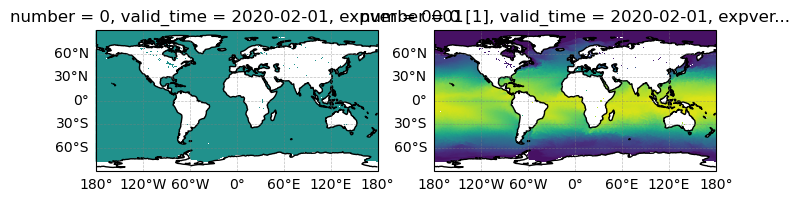

In [6]:
fig, ax = plt.subplots(1, 2, figsize=(8, 6), subplot_kw={'projection': ccrs.PlateCarree()})


# Add base features
# ax[0].add_feature(cfeature.COASTLINE)

import matplotlib as mpl
sst_mask.plot(ax=ax[0], x="longitude", y="latitude", add_colorbar=False)

sst.plot(ax=ax[1], x="longitude", y="latitude", add_colorbar=False)


for x in ax:
    x.add_feature(cfeature.COASTLINE)
    gl = x.gridlines(draw_labels=True, 
                    linewidth=0.5, color='gray', alpha=0.5, linestyle='--')

    # Turn on labels on bottom and left only
    gl.top_labels = False
    gl.right_labels = False

    # Optionally format ticks (degrees + symbols)
    gl.xformatter = cticker.LongitudeFormatter()
    gl.yformatter = cticker.LatitudeFormatter()

#### load atmospheric data

In [7]:
#  Extract level and compute thickness
levels = ds_air.pressure_level
thickness = levels.diff('pressure_level')  # Layer thickness (e.g., in hPa)

# Mask to keep only levels between 650 and 750
mask = (levels >= 550) & (levels <= 850)
thickness = thickness.where(mask, drop=True)


# Compute weighted average over level
weighted_avg_w = (
    (ds_air.w * thickness).sum(dim='pressure_level') 
    / thickness.sum(dim='pressure_level')
)
weighted_avg_D = (
    (ds_air.d * thickness).sum(dim='pressure_level') 
    / thickness.sum(dim='pressure_level')
)

# Now weighted_avg is a Dask array with dims (time, cell)
# You can compute it later if needed:
# weighted_avg = weighted_avg.compute()

mask_subsidence = xr.where((weighted_avg_w > 0.)&((weighted_avg_D > 0.)), 1.0, np.nan).compute()   #(weighted_avg > 0.).compute().isel(time=0)

# cell_indices = np.where(sst_mask)[0]
# mask_subsidence = mask_subsidence.isel(cell=cell_indices)



In [8]:
# # Extract the cell coordinates
# cell_lons = mask_subsidence.lon  # shape (cell,)
# cell_lats = mask_subsidence.lat  # shape (cell,)

# # Interpolate sst_mask onto the cell points
# sst_mask_on_cells = sst_mask.sel(
#     lat=cell_lats,
#     lon=cell_lons,
#     method="nearest"
# )
# # Result has dimensions (time, cell) — matches mask_subsidence

# # Now apply the mask
# mask_subsidence_masked = mask_subsidence.where(sst_mask_on_cells == 1.)
# mask_subsidence_masked

In [9]:
lon_mask = xr.where((ds_air.longitude > 0.)
                         &(ds_air.longitude < 20.)
                         |(ds_air.longitude > 200.), 1.0, np.nan)
lat_mask = xr.where(((ds_air.latitude > -45.)
                    &(ds_air.latitude < 45.)), 1., np.nan)

tropical_mask = (lon_mask*lat_mask).compute()

In [10]:
total_mask = (sst_mask) * (mask_subsidence) * (tropical_mask)

In [11]:
Natlantic_mask = xr.where((ds_air.latitude > 10.)
                         &(ds_air.latitude < 25.)
                         &(ds_air.longitude > 290.)
                         &(ds_air.longitude < 310.), 1.0, np.nan).compute()

Satlantic_mask = xr.where((ds_air.latitude > -15.)
                         &(ds_air.latitude < -5.)
                         &(ds_air.longitude > 340.)
                         &(ds_air.longitude < 350.), 1.0, np.nan).compute()

Spacific_mask = xr.where((ds_air.latitude > -15.)
                         &(ds_air.latitude < 0.)
                         &(ds_air.longitude > 250.)
                         &(ds_air.longitude < 280.), 1.0, np.nan).compute()

Npacific_mask = xr.where((ds_air.latitude > 25.)
                         &(ds_air.latitude < 35.)
                         &(ds_air.longitude > 220.)
                         &(ds_air.longitude < 240.), 1.0, np.nan).compute()



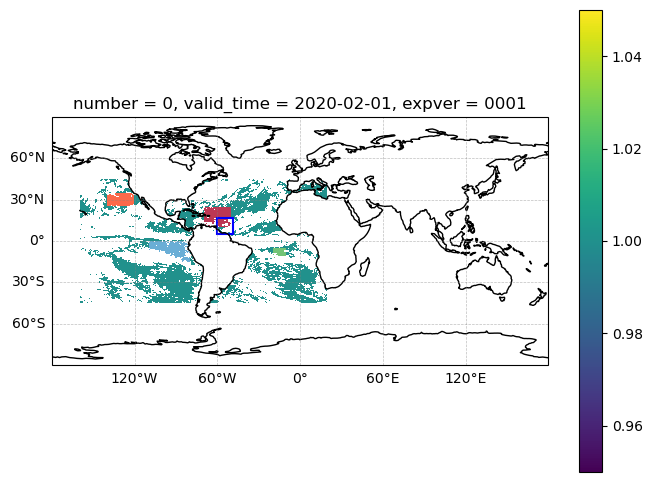

In [12]:

fig = plt.figure(figsize=(8, 6))
ax = plt.axes(projection=ccrs.PlateCarree())

# Add base features
ax.add_feature(cfeature.COASTLINE)


total_mask.plot(x="longitude", y="latitude")
(total_mask*Natlantic_mask).plot(x="longitude", y="latitude", cmap="inferno", add_colorbar=False)

(total_mask*Satlantic_mask).plot(x="longitude", y="latitude", cmap="Greens", add_colorbar=False)
(total_mask*Spacific_mask).plot(x="longitude", y="latitude", cmap="Blues", add_colorbar=False)
(total_mask*Npacific_mask).plot(x="longitude", y="latitude", cmap="Reds", add_colorbar=False)


gl = ax.gridlines(draw_labels=True, 
                  linewidth=0.5, color='gray', alpha=0.5, linestyle='--')

# Turn on labels on bottom and left only
gl.top_labels = False
gl.right_labels = False

# Optionally format ticks (degrees + symbols)
gl.xformatter = cticker.LongitudeFormatter()
gl.yformatter = cticker.LatitudeFormatter()


from matplotlib.patches import Rectangle
lat_min, lon_min = 5, 300
lat_max, lon_max = 17, 311
ax.add_patch(Rectangle(
        xy=(lon_min, lat_min),          # bottom-left corner (lon, lat)
        width=lon_max - lon_min,        # 11 degrees
        height=lat_max - lat_min,       # 12 degrees
        transform=ccrs.PlateCarree(),
        linewidth=1.5,
        edgecolor='blue',
        facecolor='none'                # transparent fill
    ))

In [13]:
(total_mask*Natlantic_mask).notnull().sum().values

array(3760)

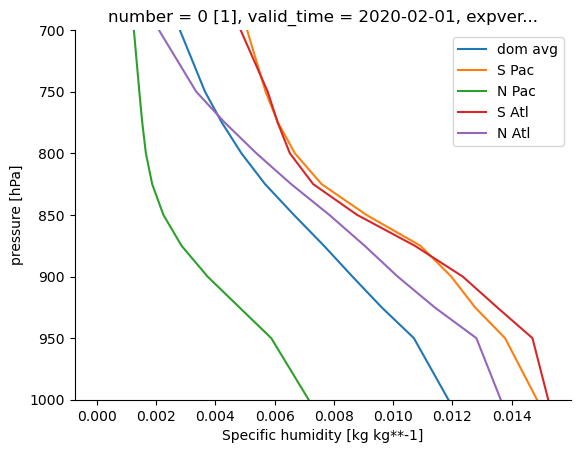

In [14]:
(ds_air.q*total_mask).mean(dim=["latitude", "longitude"]).plot.line(y="pressure_level", label="dom avg")
(ds_air.q*Spacific_mask).mean(dim=["latitude", "longitude"]).plot.line(y="pressure_level", label="S Pac")
(ds_air.q*Npacific_mask).mean(dim=["latitude", "longitude"]).plot.line(y="pressure_level", label="N Pac")
(ds_air.q*Satlantic_mask).mean(dim=["latitude", "longitude"]).plot.line(y="pressure_level", label="S Atl")
(ds_air.q*Natlantic_mask).mean(dim=["latitude", "longitude"]).plot.line(y="pressure_level", label="N Atl")

plt.gca().invert_yaxis()
plt.ylim(1000,700)
plt.legend()


for spine in ['top', 'right']:
        plt.gca().spines[spine].set_visible(False)

#### collect data to run bulk model

In [15]:
ds_air_sub = ds_air.sel(
    latitude=slice(25., 10.),
    longitude=slice(290., 310.)
)

ds_sst_sub = (ds_sst.squeeze()).sel(
    latitude=slice(25., 10.),
    longitude=slice(290., 310.)
)


Natlantic_mask_sub = (total_mask*Natlantic_mask).sel(
    latitude=slice(25., 10.),
    longitude=slice(290., 310.)
)

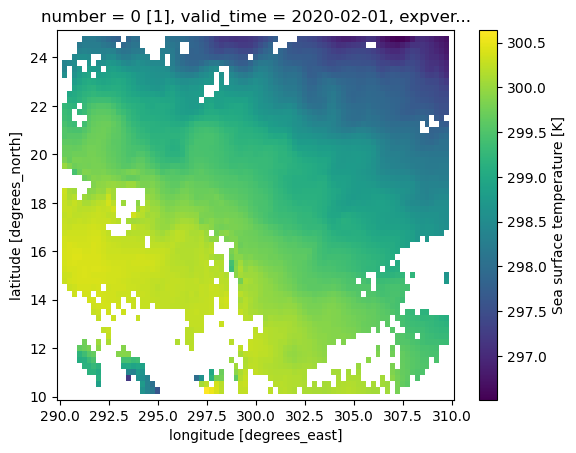

In [16]:
(ds_sst_sub.sst*Natlantic_mask_sub).plot(x="longitude", y="latitude")

In [17]:
weighted_avg_D_sub = (
    (ds_air_sub.d * thickness).sum(dim='pressure_level') 
    / thickness.sum(dim='pressure_level')
)

In [18]:
entrainment_level = 800. # hPa
ref_p = 1000.            # hPa

cpd  = 1004.67           # J/K/kg
Rd = 287.1
frac_Ustar = (0.9)*xr.ones_like(ds_sst_sub.sst).fillna(0.)

Omega = 2*np.pi/86400 # [rad/s] Earth rotation.
latitude0 = 10 # degree N
f = (Omega * np.sin(latitude0*np.pi/180))*xr.ones_like(sst).fillna(0.)


## selecting only NAtlantic now
mask_in_use = Natlantic_mask_sub

# ## these will be needed to select good lats and lons after
# good_indices = mask_in_use.notnull().compute()
# lat_sel = ds_air.latitude.compute().where(good_indices, drop=True)
# lon_sel = ds_air.longitude.compute().where(good_indices, drop=True)

sst = (ds_sst_sub.sst)*mask_in_use

q_free  = ds_air_sub.q.sel(pressure_level=entrainment_level)*mask_in_use
th_free = ((ds_air_sub.t.sel(pressure_level=entrainment_level))*((ref_p/entrainment_level)**(0.286)))*mask_in_use
D       = weighted_avg_D_sub*mask_in_use
U_free  = ds_air_sub.u.sel(pressure_level=entrainment_level)*mask_in_use
V_free  = ds_air_sub.v.sel(pressure_level=entrainment_level)*mask_in_use

ps      = (ds_sst_sub.msl).fillna(1000.)/100.

th_s = (sst*(ref_p/ps)**(Rd/cpd)) 
q_s = (bulk_model_code.qsea(sst-273.15,ps)*1e-3)


# initial conditions vector  
y0 = [(100*xr.ones_like(sst)).fillna(0.),
      (q_s - q_free).fillna(0.),
      (th_s-2.).fillna(0.), 
      (U_free - 3.).fillna(0.), 
      (V_free -1.).fillna(0.)]

# y0 = [x.fillna(0.) for x in y0]

max_t = 3.55e5
dt_max = 60
time = [0, max_t]


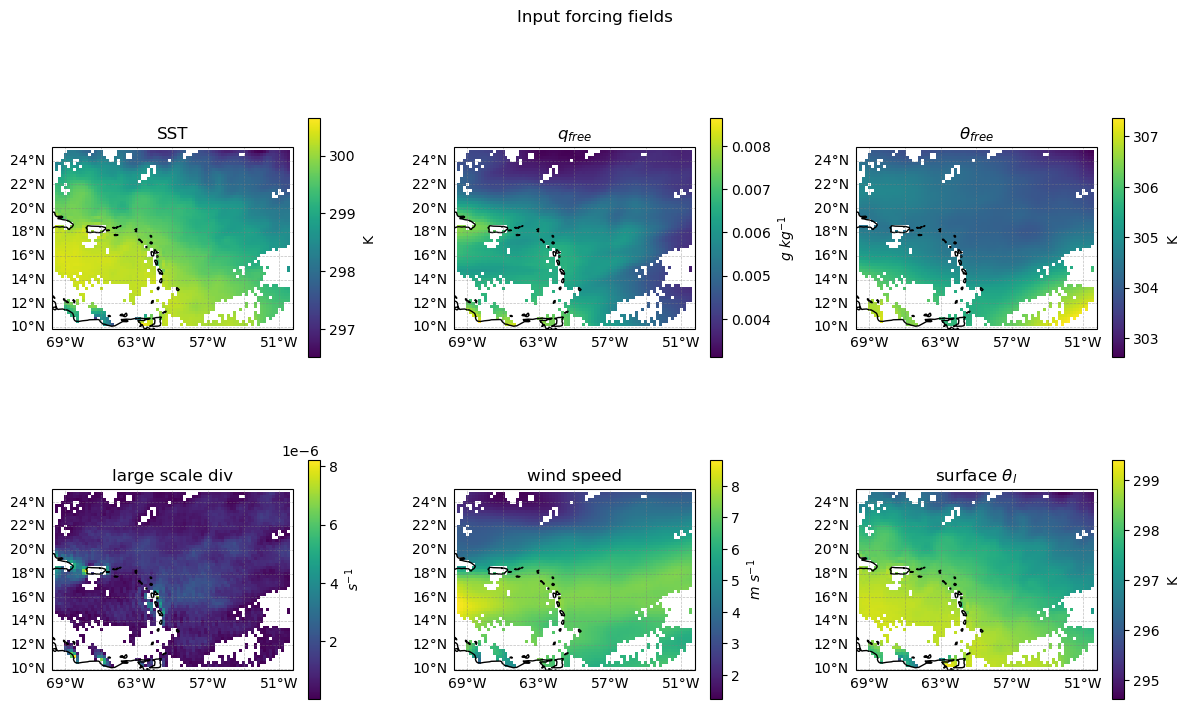

In [19]:
fig, ax = plt.subplots(2, 3, figsize=(12, 8), 
                       subplot_kw={'projection': ccrs.PlateCarree()})
ax = ax.flatten()

fig.suptitle("Input forcing fields")

titles   = ["SST", 
            r"$q_{free}$", 
            r"$\theta_{free}$", 
            "large scale div", 
            "wind speed", 
            r"surface $\theta_l$"]

cb_labels = ["K", 
             r"$g~kg^{-1}$", 
             "K", 
             r"$s^{-1}$", 
             r"$m~s^{-1}$", 
             "K"]

cbar_kw = dict(shrink=0.6, aspect=20)

plots = [
    sst.plot(ax=ax[0], x="longitude", y="latitude", cbar_kwargs={"label": cb_labels[0], **cbar_kw}),
    q_free.plot(ax=ax[1], x="longitude", y="latitude", cbar_kwargs={"label": cb_labels[1], **cbar_kw}),
    th_free.plot(ax=ax[2], x="longitude", y="latitude", cbar_kwargs={"label": cb_labels[2], **cbar_kw}),
    D.plot(ax=ax[3], x="longitude", y="latitude", cbar_kwargs={"label": cb_labels[3], **cbar_kw}),
    ((U_free**2 + V_free**2)**0.5).plot(ax=ax[4], x="longitude", y="latitude", cbar_kwargs={"label": cb_labels[4], **cbar_kw}),
    th_s.plot(ax=ax[5], x="longitude", y="latitude", cbar_kwargs={"label": cb_labels[5], **cbar_kw}),
]

for a, title in zip(ax, titles):
    a.set_title(title)


for x in ax:
    x.add_feature(cfeature.COASTLINE)
    gl = x.gridlines(draw_labels=True, 
                    linewidth=0.5, color='gray', alpha=0.5, linestyle='--')

    # Turn on labels on bottom and left only
    gl.top_labels = False
    gl.right_labels = False

    # Optionally format ticks (degrees + symbols)
    gl.xformatter = cticker.LongitudeFormatter()
    gl.yformatter = cticker.LatitudeFormatter()


plt.tight_layout()

In [20]:
import os

# Respect the CPUs allocated to your job by the scheduler (SLURM/PBS)
n_workers = int(os.environ.get("SLURM_CPUS_PER_TASK", os.cpu_count()))
print(f"Using {n_workers} workers")

Using 256 workers


In [21]:
import importlib
importlib.reload(bulk_parallelized)

<module 'bulk_parallelized' from '/work/mh1498/m301248/TCO_data/QJRMS_0316/bulk_validation/bulk_parallelized.py'>

In [22]:
def to_np(x):
    return np.ascontiguousarray(
        x.values if hasattr(x, "values") else np.asarray(x),
        dtype=np.float64
    )

# Stack y0 → (nlat, nlon, 5)
y0_field = np.stack([to_np(y0[k]) for k in range(5)], axis=-1)

result = bulk_parallelized.solve_bulk_all(
    time[0], time[-1], dt_max,
    y0_field,
    to_np(sst), to_np(D),      to_np(q_free), to_np(th_free),
    to_np(ps),  to_np(f),      to_np(U_free), to_np(V_free),
    to_np(frac_Ustar),
    n_jobs=-1
)

[Parallel(n_jobs=-1)]: Using backend LokyBackend with 256 concurrent workers.
[Parallel(n_jobs=-1)]: Done 288 tasks      | elapsed:   17.2s
[Parallel(n_jobs=-1)]: Done 738 tasks      | elapsed:   34.0s
[Parallel(n_jobs=-1)]: Done 1288 tasks      | elapsed:   54.5s
[Parallel(n_jobs=-1)]: Done 1938 tasks      | elapsed:  1.3min
[Parallel(n_jobs=-1)]: Done 2688 tasks      | elapsed:  1.7min
[Parallel(n_jobs=-1)]: Done 3538 tasks      | elapsed:  2.1min
[Parallel(n_jobs=-1)]: Done 4941 out of 4941 | elapsed:  2.6min finished


In [51]:
h = xr.DataArray(result[:,:,0], name="h", dims=["latitude", "longitude"], coords={"latitude":ds_sst_sub.latitude.values, "longitude":ds_sst_sub.longitude.values})
q = xr.DataArray(result[:,:,1], name="q", dims=["latitude", "longitude"], coords={"latitude":ds_sst_sub.latitude.values, "longitude":ds_sst_sub.longitude.values})
t = xr.DataArray(result[:,:,2], name="t", dims=["latitude", "longitude"], coords={"latitude":ds_sst_sub.latitude.values, "longitude":ds_sst_sub.longitude.values})
u = xr.DataArray(result[:,:,3], name="u", dims=["latitude", "longitude"], coords={"latitude":ds_sst_sub.latitude.values, "longitude":ds_sst_sub.longitude.values})
v = xr.DataArray(result[:,:,4], name="v", dims=["latitude", "longitude"], coords={"latitude":ds_sst_sub.latitude.values, "longitude":ds_sst_sub.longitude.values})


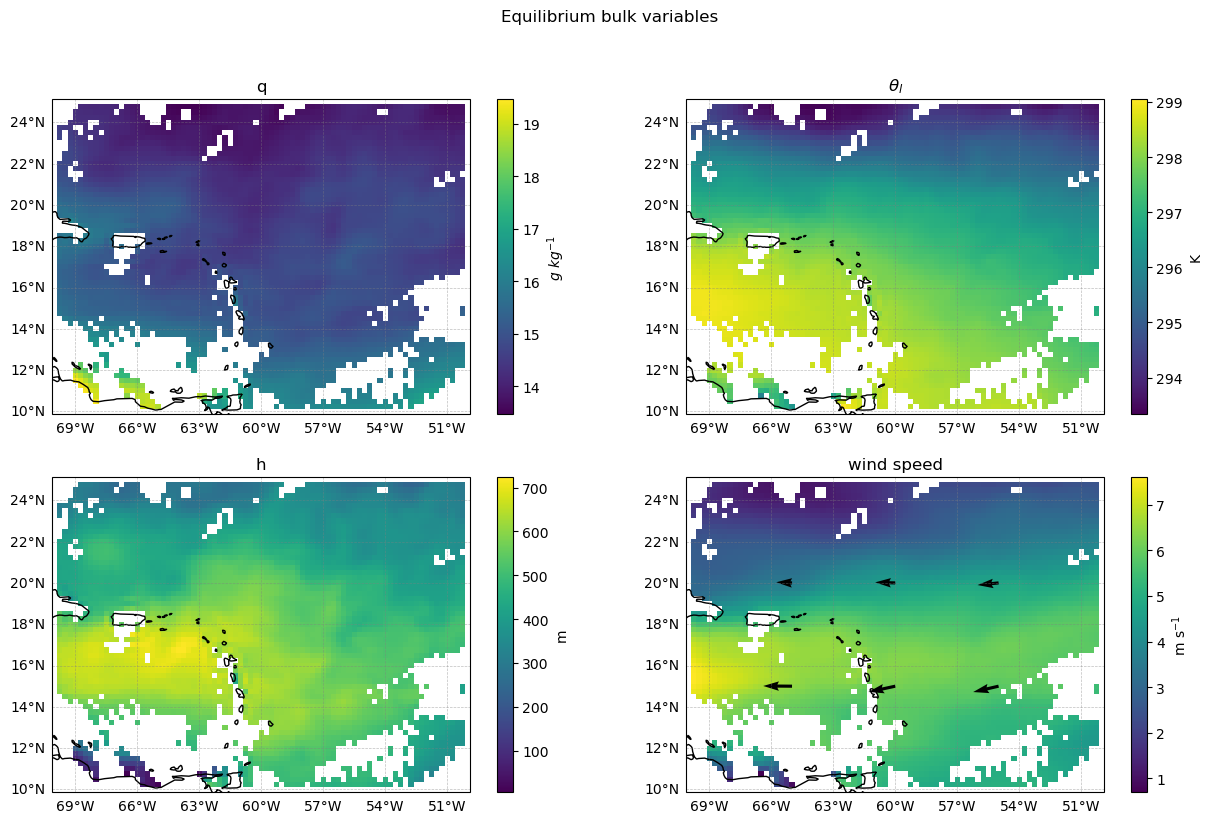

In [52]:
fig, ax = plt.subplots(2, 2, figsize=(15, 9), subplot_kw={'projection': ccrs.PlateCarree()})
fig.suptitle("Equilibrium bulk variables")


####### moisture  #######
p = (q*1e3).plot(ax=ax[0,0] , x="longitude", y="latitude")
p.colorbar.set_label(r"$g~kg^{-1}$")
ax[0,0].set_title("q")


######  temperature  ######
p = t.plot(ax=ax[0,1] ,x="longitude", y="latitude")
p.colorbar.set_label(r"K")
ax[0,1].set_title(r"$\theta_{l}$")


####### ML depth  ######
p = h.plot(ax=ax[1,0] ,x="longitude", y="latitude")
p.colorbar.set_label(r"m")
ax[1,0].set_title(r"h")



####### wind speed and dir   #########

p = ((u**2+v**2)**0.5).plot(ax=ax[1,1] ,x="longitude", y="latitude")

step = 20  # plot every 3rd point
ax[1,1].quiver(
    u.longitude.values[::step],
    u.latitude.values[::step],
    u.values[::step, ::step],
    v.values[::step, ::step],
)

p.colorbar.set_label(r"$\rm m~s^{-1}$")
ax[1,1].set_title(r"wind speed")


for x in ax.flatten():
    x.add_feature(cfeature.COASTLINE)
    gl = x.gridlines(draw_labels=True, 
                    linewidth=0.5, color='gray', alpha=0.5, linestyle='--')

    # Turn on labels on bottom and left only
    gl.top_labels = False
    gl.right_labels = False

    # Optionally format ticks (degrees + symbols)
    gl.xformatter = cticker.LongitudeFormatter()
    gl.yformatter = cticker.LatitudeFormatter()


    for spine in ['top', 'right']:
        x.spines[spine].set_visible(False)

check how these compare to ERA5 output - where is BL height?

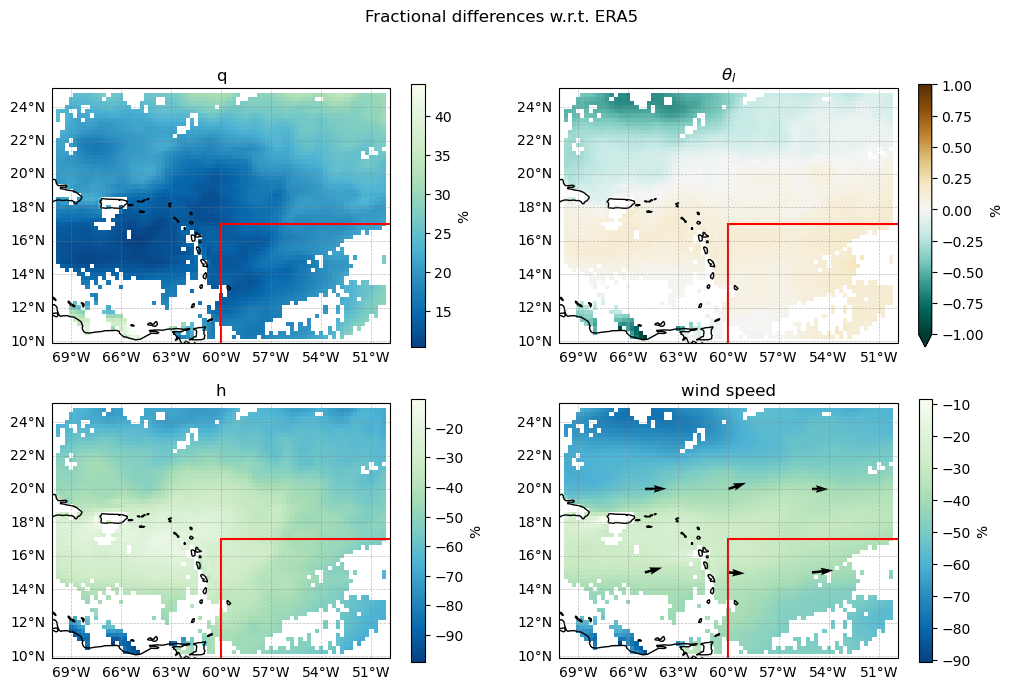

In [53]:
fig, ax = plt.subplots(2, 2, figsize=(12, 7.5), subplot_kw={'projection': ccrs.PlateCarree()})
fig.suptitle("Fractional differences w.r.t. ERA5")


####### moisture  #######
q_era5 = ds_air_sub.q.sel(pressure_level=slice(1000,925)).mean(dim="pressure_level")
p = (100*(q - q_era5)/(q_era5)).plot(ax=ax[0,0] , x="longitude", y="latitude", cmap="GnBu_r")
p.colorbar.set_label('%')  #(r"$g~kg^{-1}$")
ax[0,0].set_title("q")


######  temperature  ######
theta_era5 = (ds_air_sub.t*(1000./ds_air_sub.pressure_level)**(0.283)).sel(pressure_level=slice(1000,925)).mean(dim="pressure_level")
p = (100*(t - theta_era5)/theta_era5).plot(ax=ax[0,1] ,x="longitude", y="latitude", cmap="BrBG_r", vmin=-1, vmax=1.)
p.colorbar.set_label('%')  #(r"K")
ax[0,1].set_title(r"$\theta_{l}$")


####### ML depth  ######
p = (100*(h - ds_sst_sub.blh)/ds_sst_sub.blh).plot(ax=ax[1,0] ,x="longitude", y="latitude", cmap="GnBu_r")
p.colorbar.set_label('%')  #(r"m")
ax[1,0].set_title(r"h")



####### wind speed and dir   #########
u_era5 = ds_air_sub.u.sel(pressure_level=slice(1000,925)).mean(dim="pressure_level")
v_era5 = ds_air_sub.v.sel(pressure_level=slice(1000,925)).mean(dim="pressure_level")
wind_era5 = (u_era5**2 + v_era5**2)**(0.5)

p = (100*((u**2+v**2)**0.5 - wind_era5)/wind_era5).plot(ax=ax[1,1] ,x="longitude", y="latitude", cmap="GnBu_r")

step = 20  # plot every 3rd point
ax[1,1].quiver(
    u.longitude.values[::step],
    u.latitude.values[::step],
    (u - u_era5).values[::step, ::step],
    (v - v_era5).values[::step, ::step],
)

p.colorbar.set_label('%')   #(r"$\rm m~s^{-1}$")
ax[1,1].set_title(r"wind speed")




## add simulation box
from matplotlib.patches import Rectangle
lat_min, lon_min = 5, 300
lat_max, lon_max = 17, 311

for x in ax.flatten():
    x.add_feature(cfeature.COASTLINE)
    gl = x.gridlines(draw_labels=True, 
                    linewidth=0.5, color='gray', alpha=0.5, linestyle='--')

    # Turn on labels on bottom and left only
    gl.top_labels = False
    gl.right_labels = False

    # Optionally format ticks (degrees + symbols)
    gl.xformatter = cticker.LongitudeFormatter()
    gl.yformatter = cticker.LatitudeFormatter()

    x.add_patch(Rectangle(
        xy=(lon_min, lat_min),          # bottom-left corner (lon, lat)
        width=lon_max - lon_min,        # 11 degrees
        height=lat_max - lat_min,       # 12 degrees
        transform=ccrs.PlateCarree(),
        linewidth=1.5,
        edgecolor='red',
        facecolor='none'                # transparent fill
    ))


    for spine in ['top', 'right']:
        x.spines[spine].set_visible(False)

#### with discrete contouring

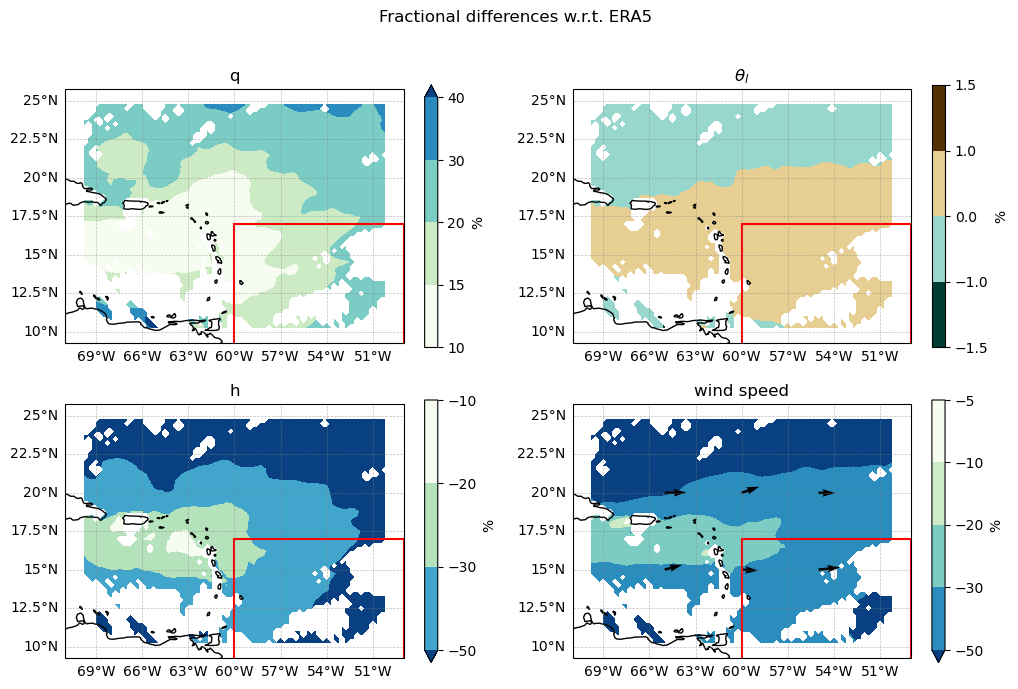

In [54]:
fig, ax = plt.subplots(2, 2, figsize=(12, 7.5), subplot_kw={'projection': ccrs.PlateCarree()})
fig.suptitle("Fractional differences w.r.t. ERA5")


####### moisture  #######
q_era5 = ds_air_sub.q.sel(pressure_level=slice(1000,925)).mean(dim="pressure_level")
p = (100*(q - q_era5)/(q_era5)).plot.contourf(ax=ax[0,0] , x="longitude", y="latitude", levels=[10,15,20,30,40], cmap="GnBu")
p.colorbar.set_label('%')  #(r"$g~kg^{-1}$")
ax[0,0].set_title("q")


######  temperature  ######
theta_era5 = (ds_air_sub.t*(1000./ds_air_sub.pressure_level)**(0.283)).sel(pressure_level=slice(1000,925)).mean(dim="pressure_level")
p = (100*(t - theta_era5)/theta_era5).plot.contourf(ax=ax[0,1] ,x="longitude", y="latitude", levels=[-1.5,-1, 0, 1., 1.5], cmap="BrBG_r") #, vmin=-1, vmax=1.)
p.colorbar.set_label('%')  #(r"K")
ax[0,1].set_title(r"$\theta_{l}$")


####### ML depth  ######
p = (100*(h - ds_sst_sub.blh)/ds_sst_sub.blh).plot.contourf(ax=ax[1,0] ,x="longitude", y="latitude", levels=[-10, -20,-30, -50], cmap="GnBu_r")
p.colorbar.set_label('%')  #(r"m")
ax[1,0].set_title(r"h")



####### wind speed and dir   #########
u_era5 = ds_air_sub.u.sel(pressure_level=slice(1000,925)).mean(dim="pressure_level")
v_era5 = ds_air_sub.v.sel(pressure_level=slice(1000,925)).mean(dim="pressure_level")
wind_era5 = (u_era5**2 + v_era5**2)**(0.5)

p = (100*((u**2+v**2)**0.5 - wind_era5)/wind_era5).plot.contourf(ax=ax[1,1] ,x="longitude", y="latitude", levels=[-5, -10, -20,-30, -50], cmap="GnBu_r")

step = 20  # plot every 3rd point
ax[1,1].quiver(
    u.longitude.values[::step],
    u.latitude.values[::step],
    (u - u_era5).values[::step, ::step],
    (v - v_era5).values[::step, ::step],
)

p.colorbar.set_label('%')   #(r"$\rm m~s^{-1}$")
ax[1,1].set_title(r"wind speed")




## add simulation box
from matplotlib.patches import Rectangle
lat_min, lon_min = 5, 300
lat_max, lon_max = 17, 311

for x in ax.flatten():
    x.add_feature(cfeature.COASTLINE)
    gl = x.gridlines(draw_labels=True, 
                    linewidth=0.5, color='gray', alpha=0.5, linestyle='--')

    # Turn on labels on bottom and left only
    gl.top_labels = False
    gl.right_labels = False

    # Optionally format ticks (degrees + symbols)
    gl.xformatter = cticker.LongitudeFormatter()
    gl.yformatter = cticker.LatitudeFormatter()

    x.add_patch(Rectangle(
        xy=(lon_min, lat_min),          # bottom-left corner (lon, lat)
        width=lon_max - lon_min,        # 11 degrees
        height=lat_max - lat_min,       # 12 degrees
        transform=ccrs.PlateCarree(),
        linewidth=1.5,
        edgecolor='red',
        facecolor='none'                # transparent fill
    ))


    for spine in ['top', 'right']:
        x.spines[spine].set_visible(False)

In [55]:
y_eq = [h.values, q.values, t.values, u.values, v.values]

# y, SST, ps, q_free, th_free, frac_Ustar

diagnostics = bulk_model_code.compute_diagnostics(y_eq, to_np(sst), to_np(ps),  to_np(q_free), to_np(th_free), to_np(frac_Ustar))

In [70]:
lhf = xr.DataArray(diagnostics['LHF'], name="lhf", dims=["latitude", "longitude"], coords={"latitude":ds_sst_sub.latitude.values, "longitude":ds_sst_sub.longitude.values})
shf = xr.DataArray(diagnostics['SHF'], name="shf", dims=["latitude", "longitude"], coords={"latitude":ds_sst_sub.latitude.values, "longitude":ds_sst_sub.longitude.values})

E = xr.DataArray(diagnostics['E'], name="E", dims=["latitude", "longitude"], coords={"latitude":ds_sst_sub.latitude.values, "longitude":ds_sst_sub.longitude.values})


#### reconstruct instantaneous surface heats -- DOESNT WORK

In [28]:
for_radiation = xr.open_dataset("/work/mh1498/m301248/TCO_data/fluxes_data/EUREC4A_IngrFlux.nc")
sw = for_radiation["sw_global"].groupby("time.month").mean().isel(month=1, cell=0)
lw = for_radiation["lw_diff"].groupby("time.month").mean().isel(month=1, cell=0)


In [30]:
import sys
sys.path.append("/work/mh1498/m301248/TCO_data/COARE-algorithm/Python/COARE3.5")

from meteo import qsat

In [31]:
ds_sst_sub

<xarray.Dataset> Size: 140kB
Dimensions:     (latitude: 61, longitude: 81)
Coordinates:
  * latitude    (latitude) float64 488B 25.0 24.75 24.5 ... 10.5 10.25 10.0
  * longitude   (longitude) float64 648B 290.0 290.2 290.5 ... 309.5 309.8 310.0
    number      int64 8B ...
    valid_time  datetime64[ns] 8B 2020-02-01
    expver      <U4 16B ...
Data variables:
    sst         (latitude, longitude) float32 20kB 297.7 297.7 ... 299.2 299.1
    msl         (latitude, longitude) float32 20kB ...
    blh         (latitude, longitude) float32 20kB ...
    u10         (latitude, longitude) float32 20kB ...
    v10         (latitude, longitude) float32 20kB ...
    d2m         (latitude, longitude) float32 20kB ...
    t2m         (latitude, longitude) float32 20kB ...
Attributes:
    GRIB_centre:             ecmf
    GRIB_centreDescription:  European Centre for Medium-Range Weather Forecasts
    GRIB_subCentre:          0
    Conventions:             CF-1.7
    institution:             European Centre for Medium-Range Weather Forecasts
    history:                 2026-03-25T14:05 GRIB to CDM+CF via cfgrib-0.9.1...

In [ ]:
# compute RH at 2m
e  = qsat(ds_sst_sub["d2m"].values-273.15, ds_sst_sub.msl.values/100.)
es = qsat(ds_sst_sub["t2m"].values-273.15, ds_sst_sub.msl.values/100.)
rh2 = e/es

u10, v10 = ds_sst_sub["u10"], ds_sst_sub["v10"]
u = (u10**2 + v10**2)**0.5
t = ds_sst_sub["t2m"]
rh = rh2
ts = ds_sst_sub["sst"]
P = ds_sst_sub["msl"]/100.    # hPa
Rs = sw*xr.ones_like(ts)
Rl = lw*xr.ones_like(ts)


import coare35vn

output = coare35vn.coare35vn(u=u.values.flatten(),
                             t=t.values.flatten()-273.15,
                             rh=100*rh.flatten(),
                             ts=ts.values.flatten()-273.15,
                             P=P.values.flatten(),
                             Rs=Rs.values.flatten(),
                             Rl=Rl.values.flatten(), 
                             zu=10, zt=2, zq=2, lat=13, zi=600, rain=None, cp=None, sigH=None, jcool=1)

output = output.reshape((61,81,5))


In [71]:
lhf_era5 = xr.DataArray(output[:,:,1], name="lhf", dims={"latitude", "longitude"}, coords={"latitude":ds_sst_sub.latitude.values, "longitude":ds_sst_sub.longitude.values})
shf_era5 = xr.DataArray(output[:,:,0], name="shf", dims={"latitude", "longitude"}, coords={"latitude":ds_sst_sub.latitude.values, "longitude":ds_sst_sub.longitude.values})


### bulk reconstruction of surface fluxes

In [63]:
from meteo import qsea
q_star = qsea(sst-273.15, ds_sst_sub["msl"]/100.)*1e-3

u10, v10 = ds_sst_sub["u10"], ds_sst_sub["v10"]
u = (u10**2 + v10**2)**0.5

Lv = 2.5e6
cp = 1004.67
C  = 1e-3
rho_a = 1.2

lhf_bulk = rho_a*Lv*C*u.values*(q_star - q_era5)
shf_bulk = rho_a*cp*C*u.values*(sst - theta_era5)

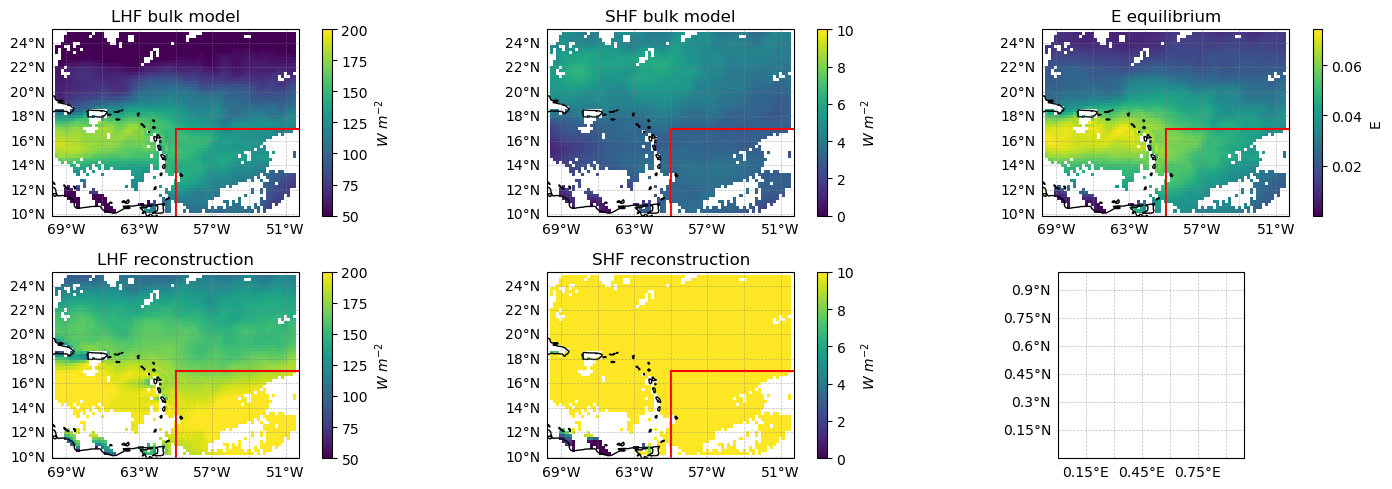

In [73]:
fig, ax = plt.subplots(2,3, figsize=(15, 5), subplot_kw={'projection': ccrs.PlateCarree()})


p = lhf.plot(ax=ax[0,0] , x="longitude", y="latitude", cmap="viridis", vmin=50., vmax=200., add_colorbar=False)
plt.colorbar(p, ax=ax[0,0], label=r"$W~m^{-2}$")
ax[0,0].set_title("LHF bulk model")

p = shf.plot(ax=ax[0,1] , x="longitude", y="latitude", cmap="viridis", vmin=0, vmax=10., add_colorbar=False)
plt.colorbar(p, ax=ax[0,1], label=r"$W~m^{-2}$")
ax[0,1].set_title("SHF bulk model")

E.plot(ax=ax[0,2] , x="longitude", y="latitude", cmap="viridis")
ax[0,2].set_title("E equilibrium")

# (100*(lhf-lhf_era5)/lhf_era5).plot.contourf(ax=ax[1,0] , x="longitude", y="latitude", levels=[0, -10, -20,-30, -50], cmap="GnBu_r")
# (100*(shf-shf_era5)/shf_era5).plot.contourf(ax=ax[1,1] , x="longitude", y="latitude", levels=[-30, -50, -80, -90, -100], cmap="GnBu_r")
p = lhf_bulk.plot(ax=ax[1,0] , x="longitude", y="latitude", cmap="viridis", vmin=50., vmax=200., add_colorbar=False)
plt.colorbar(p, ax=ax[1,0], label=r"$W~m^{-2}$")
ax[1,0].set_title("LHF reconstruction")


p = shf_bulk.plot(ax=ax[1,1] , x="longitude", y="latitude", cmap="viridis", vmin=0, vmax=10., add_colorbar=False)
plt.colorbar(p, ax=ax[1,1], label=r"$W~m^{-2}$")
ax[1,1].set_title("SHF reconstruction")


for x in ax.flatten():
    x.add_feature(cfeature.COASTLINE)
    gl = x.gridlines(draw_labels=True, 
                    linewidth=0.5, color='gray', alpha=0.5, linestyle='--')

    # Turn on labels on bottom and left only
    gl.top_labels = False
    gl.right_labels = False

    # Optionally format ticks (degrees + symbols)
    gl.xformatter = cticker.LongitudeFormatter()
    gl.yformatter = cticker.LatitudeFormatter()

    x.add_patch(Rectangle(
        xy=(lon_min, lat_min),          # bottom-left corner (lon, lat)
        width=lon_max - lon_min,        # 11 degrees
        height=lat_max - lat_min,       # 12 degrees
        transform=ccrs.PlateCarree(),
        linewidth=1.5,
        edgecolor='red',
        facecolor='none'                # transparent fill
    ))
plt.tight_layout()

#### old stuff from now on

<module 'bulk_model_code' from '/work/mh1498/m301248/TCO_data/QJRMS_0316/bulk_validation/bulk_model_code.py'>

In [ ]:
solutions = []


# class IntegrationDiverged(Exception):
#     pass
converged_mask = np.ones(cells_sel.values.size, dtype=bool)

for i in range(cells_sel.values.size):

    if i < 10:
        print(i)

    if i == ( (cells_sel.values.size)//2 ):
        print("half way!")

    try:
        sol = solve_ivp(
            bulk_model_code.bulk_ERA5,
            time,
            [y0[0][i].values.item(), y0[1][i].values.item(), y0[2][i].values.item(), y0[3][i].values.item(), y0[4][i].values.item()],
            dense_output=True,
            max_step=dt_max,
            args=(
                sst_clean[i].values, D_clean[i].values, q_free_clean[i].values, th_free_clean[i].values,
                ps_clean[i].values, f, U_free_clean[i].values, V_free_clean[i].values, frac_Ustar,
            ),
        )
        solutions.append(sol)

    except bulk_model_code.IntegrationDiverged as e:
        print(f"Point {i} diverged — skipping. Reason: {e}")
        converged_mask[i] = False
        solutions.append(None)   # keep indexing consistent

In [45]:
import numpy as np
from scipy.integrate import solve_ivp
import warnings

def idx(x, i):
    """Index into x[i] only if x is an array, otherwise return scalar."""
    return x[i] if x.ndim > 0 else x.item()

n_vars, n_cells = y0.shape

def to_np(x):
    return x.values if hasattr(x, "values") else np.asarray(x)

sst_np        = to_np(sst)
D_np          = to_np(D)
q_free_np     = to_np(q_free)
th_free_np    = to_np(th_free)
ps_np         = to_np(ps)
f_np          = to_np(f)
U_free_np     = to_np(U_free)
V_free_np     = to_np(V_free)
frac_Ustar_np = to_np(frac_Ustar)
y0_np         = to_np(y0)

# --- Failure tracking (mutable, so the closure can write to it) ---
active       = np.ones(n_cells, dtype=bool)   # True  = still integrating
failed_at_t  = np.full(n_cells, np.nan)        # time of first failure per cell
failure_log  = []                              # (t, cell_idx, exception_str)

def vec_func_flat(t, y_flat, sst, D, q_free, th_free, ps, f,
                  U_free, V_free, frac_Ustar):

    Y    = y_flat.reshape(n_vars, n_cells)
    dYdt = np.zeros_like(Y)          # zeros → frozen cells stay frozen

    for i in range(n_cells):
        if (i/n_cells == 0.5):
            print("half domain!")

        if not active[i]:            # already failed — keep derivative = 0
            continue

        try:
            with warnings.catch_warnings():
                warnings.simplefilter("error", RuntimeWarning)
                dYdt[:, i] = bulk_model_code.bulk_ERA5(
                    t,
                    Y[:, i],
                    idx(sst, i), idx(D, i), idx(q_free, i), idx(th_free, i),
                    idx(ps, i), idx(f, i), idx(U_free, i), idx(V_free, i),
                    idx(frac_Ustar, i),
                )

        except (RuntimeWarning, Exception) as e:
            active[i]      = False
            failed_at_t[i] = t
            failure_log.append((t, i, str(e)))
            # dYdt[:, i] already 0 — cell is now frozen
            # print(f"[t={t:.4f}] cell {i} deactivated: {e}")

    return dYdt.ravel()

# --- Single solve_ivp call (identical to before) ---
sol = solve_ivp(
    vec_func_flat,
    (time[0], time[-1]),
    y0_np.ravel(),
    dense_output=True,
    max_step=dt_max,
    args=(
        sst_np, D_np, q_free_np, th_free_np, ps_np, f_np,
        U_free_np, V_free_np, frac_Ustar_np,
    ),
)

# --- Unpack results (unchanged) ---
Y_out   = sol.y.reshape(n_vars, n_cells, -1)
t_eval  = np.linspace(time[0], time[-1], 500)
Y_dense = sol.sol(t_eval).reshape(n_vars, n_cells, -1)

# --- Post-integration failure report ---
n_failed = (~active).sum()
print(f"\n{n_failed}/{n_cells} cells failed during integration.")
if n_failed:
    print("Failed cells and times:")
    for t_f, i_f, msg in failure_log:
        print(f"  cell {i_f:>5d}  t={t_f:.4f}  reason: {msg}")

# --- Mask failed cells in output (optional but recommended) ---
Y_out[  :, ~active, :] = np.nan
Y_dense[:, ~active, :] = np.nan

t crash [s]: 0.0
t crash [s]: 0.0
t crash [s]: 0.0
t crash [s]: 0.0
t crash [s]: 0.0
t crash [s]: 0.0
t crash [s]: 0.0
t crash [s]: 0.0
t crash [s]: 0.0
t crash [s]: 0.0
t crash [s]: 0.0
t crash [s]: 0.0
t crash [s]: 0.0
t crash [s]: 0.0
t crash [s]: 0.0
t crash [s]: 0.0
t crash [s]: 0.0
t crash [s]: 0.0
t crash [s]: 0.0
t crash [s]: 0.0
t crash [s]: 0.0
t crash [s]: 0.0
t crash [s]: 0.0
t crash [s]: 0.0
t crash [s]: 0.0
t crash [s]: 0.0
t crash [s]: 0.0
t crash [s]: 0.0
t crash [s]: 0.0
t crash [s]: 0.0
t crash [s]: 0.0
t crash [s]: 0.0
t crash [s]: 0.0
t crash [s]: 0.0
t crash [s]: 0.0
t crash [s]: 0.0
t crash [s]: 0.0
t crash [s]: 0.0
t crash [s]: 0.0
t crash [s]: 0.0
t crash [s]: 0.0
t crash [s]: 0.0
t crash [s]: 0.0
t crash [s]: 0.0
t crash [s]: 0.0
t crash [s]: 0.0
t crash [s]: 0.0
t crash [s]: 0.0
t crash [s]: 0.0
t crash [s]: 0.0
t crash [s]: 0.0
t crash [s]: 0.0
t crash [s]: 0.0
t crash [s]: 0.0
t crash [s]: 0.0
t crash [s]: 0.0
t crash [s]: 0.0
t crash [s]: 0.0
t crash [s]: 0

KeyboardInterrupt: 

In [ ]:
# import numpy as np
# from scipy.integrate import solve_ivp



# def idx(x, i):
#     """Index into x[i] only if x is an array, otherwise return scalar."""
#     return x[i] if x.ndim > 0 else x.item()



# n_vars, n_cells = y0.shape  # e.g. (5, 1000)

# # --- Convert xarray args to numpy once, outside the solver ---
# def to_np(x):
#     return x.values if hasattr(x, "values") else np.asarray(x)

# sst_np        = to_np(sst)
# D_np          = to_np(D)
# q_free_np     = to_np(q_free)
# th_free_np    = to_np(th_free)
# ps_np         = to_np(ps)
# f_np          = to_np(f)
# U_free_np     = to_np(U_free)
# V_free_np     = to_np(V_free)
# frac_Ustar_np = to_np(frac_Ustar)
# y0_np         = to_np(y0)   # shape (n_vars, n_cells)

# # --- Wrapper: loops over cells, passes full state vector y[:,i] to scalar func ---
# def vec_func_flat(t, y_flat, sst, D, q_free, th_free, ps, f,
#                   U_free, V_free, frac_Ustar):

#     Y = y_flat.reshape(n_vars, n_cells)   # (n_vars, n_cells)
#     dYdt = np.empty_like(Y)

#     for i in range(n_cells):
#         dYdt[:, i] = bulk_model_code.bulk_ERA5(
#             t,
#             Y[:, i],
#             idx(sst, i), idx(D, i), idx(q_free, i), idx(th_free, i), idx(ps, i),
#             idx(f, i), idx(U_free, i), idx(V_free, i), idx(frac_Ustar, i),
#         )

#     return dYdt.ravel()

# # --- Single solve_ivp call ---
# sol = solve_ivp(
#     vec_func_flat,
#     (time[0], time[-1]),              # (t_start, t_end) as a 2-tuple
#     y0_np.ravel(),                    # flatten (n_vars, n_cells) → 1D
#     dense_output=True,
#     max_step=dt_max,
#     args=(
#         sst_np, D_np, q_free_np, th_free_np, ps_np, f_np,
#         U_free_np, V_free_np, frac_Ustar_np,
#     ),
# )

# # --- Unpack results ---
# # sol.y has shape (n_vars*n_cells, n_timepoints)
# Y_out = sol.y.reshape(n_vars, n_cells, -1)   # → (n_vars, n_cells, n_timepoints)

# # If you need the dense solution evaluated at specific times:
# t_eval = np.linspace(time[0], time[-1], 500)
# Y_dense = sol.sol(t_eval).reshape(n_vars, n_cells, -1)

q_flux_s: 9.731788867337977e-05
q_s - y[1]: 0.0107056577980984
delta_q: 1.906512858754969e-05
w_star: 0.4915985880700841
th_s - y[2]: 2.0


UnboundLocalError: cannot access local variable 'sigma_q' where it is not associated with a value

In [ ]:
# import numpy as np
# from scipy.integrate import solve_ivp

# n_vars, n_cells = y0.shape  # e.g. (5, 1000)
# vec_func = np.vectorize(bulk_model_code.neggers_et_al_2006_stevens_et_al_2002_fracUstar)
# # neggers_et_al_2006_stevens_et_al_2002_fracUstar takes the following arguments
# # t,y,SST,D,q_free,th_free,ps,f,U_free,V_free, frac_Ustar

# # --- Wrapper that flattens/unflattens around your existing vec_func ---
# def vec_func_flat(t, y_flat, sst, D, q_free, th_free, ps, f,
#                   U_free, V_free, frac_Ustar):

#     Y = y_flat.reshape(n_vars, n_cells)          # 1D → 2D for vec_func

#     dYdt = vec_func(t, Y, sst, D,      # your original function,
#                     q_free, th_free, ps, f,        # unchanged
#                     U_free, V_free, frac_Ustar)

#     return dYdt.ravel()                            # 2D → 1D for solve_ivp


# # --- Convert xarray args to numpy once, outside the solver ---
# def to_np(x):
#     return x.values if hasattr(x, "values") else np.asarray(x)

# args_np = (to_np(sst), to_np(D),
#     to_np(q_free), to_np(th_free), to_np(ps), to_np(f),
#     to_np(U_free), to_np(V_free), to_np(frac_Ustar),
# )

# # --- Single solve_ivp call ---
# sol = solve_ivp(
#     vec_func_flat,
#     (time[0], time[-1]),          # (t_start, t_end) as a 2-tuple
#     y0.ravel(),            # flatten (n_vars, n_cells) → 1D
#     dense_output=True,
#     max_step=dt_max,
#     args=args_np,
# )

# # --- Unpack results ---
# # sol.y has shape (n_vars*n_cells, n_timepoints)
# Y_out = sol.y.reshape(n_vars, n_cells, -1)   # → (n_vars, n_cells, n_timepoints)

# # If you need the dense solution evaluated at specific times:
# t_eval = np.linspace(time[0], time[-1], 500)
# Y_dense = sol.sol(t_eval).reshape(n_vars, n_cells, -1)

IndexError: invalid index to scalar variable.

In [ ]:
# from scipy.integrate import solve_ivp

# f = f*total_mask
# frac_Ustar = frac_Ustar*total_mask

# vec_func = np.vectorize(bulk_model_code.neggers_et_al_2006_stevens_et_al_2002_fracUstar)

# sol = solve_ivp(vec_func, 
#                 time,
#                 y0,
#                 dense_output=True,
#                 max_step=dt_max,
#                 args=(time,y0,sst,D,q_free,th_free,ps,f,U_free,V_free, frac_Ustar))




ValueError: `y0` must be 1-dimensional.